# How reliable can a screenshot-driven agent be?

Pilot runs a loop: look at the screen, plan, act, wait 1.5 seconds, take a screenshot, ask a verifier
whether the step worked, then continue, replan or stop. Every decision comes from pixels, so every stage
can be wrong, and the errors compound across a multi-step task.

**What this notebook is, and is not.** There is no API key in this repository and no logged runs, so
nothing here is a measurement of Pilot. It is a model of the loop exactly as `backend/main.py` implements
it, driven by rates that are **assumptions, labelled as such**. The point is to find which rates matter,
which design changes move the outcome, and what an evaluation would have to measure. The code review that
prompted it is summarised at the end, with the fixes already made.

**The rates (all assumed):**

| Symbol | Meaning |
|---|---|
| $k$ | steps in a plan |
| $a$ | chance an action truly achieves its step |
| $s$ | verifier catch rate: chance it reports failure when the step truly failed |
| $e$ | verifier false-alarm rate: chance it reports failure when the step truly worked |
| $R$ | replan cap (`MAX_REPLANS`, now 3; before the fix, unlimited) |
| $m$ | median time for the page to settle after an action |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
R_ = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"

# Model calls, read off main.py: interpret + plan once; act + verify + narrate per attempt; interpret + replan per replan
CALLS_START, CALLS_ATTEMPT, CALLS_REPLAN = 2, 3, 2
WAIT = 1.5  # seconds, the fixed asyncio.sleep before the verification screenshot


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")

## 1. The loop as a Markov chain

Each attempt at a step has four outcomes, and the code's response to each is fixed:

| Truth | Verifier says | Probability | What main.py does |
|---|---|---|---|
| worked | worked | $a(1-e)$ | next step |
| worked | failed | $ae$ | replan (if replans remain), else stop |
| failed | worked | $(1-a)(1-s)$ | next step, **with a silent error carried forward** |
| failed | failed | $(1-a)s$ | replan and retry (if replans remain), else stop |

A run ends in one of three ways: **correct** (every step truly done), **silent failure** (reported complete
but some step never happened, the worst case for an agent editing CRM records), or **stopped** (the user
sees a failure). Two simplifications, both generous to the agent: after a false alarm the replanned plan
recognises the step as done, and a retried step succeeds with the same $a$.

The chain has no cycles once replans are capped (each replan raises $r$), so the exact outcome
probabilities come from a forward pass over states (step $i$, replans used $r$, error carried $w$).

In [2]:
def chain(k, a, s, e, R):
    """Exact outcome probabilities and expected model calls for the verify-replan loop."""
    mass = np.zeros((k + 1, R + 1, 2))
    mass[0, 0, 0] = 1.0
    stopped = np.zeros(2)
    calls = CALLS_START
    for i in range(k):
        for r in range(R + 1):
            for w in (0, 1):
                p = mass[i, r, w]
                if p == 0:
                    continue
                calls += p * CALLS_ATTEMPT
                mass[i + 1, r, w] += p * a * (1 - e)
                mass[i + 1, r, 1] += p * (1 - a) * (1 - s)
                if r < R:
                    calls += p * (a * e + (1 - a) * s) * CALLS_REPLAN
                    mass[i + 1, r + 1, w] += p * a * e          # false alarm: replan, step already done
                    mass[i, r + 1, w] += p * (1 - a) * s        # caught failure: replan and retry
                else:
                    stopped[w] += p * (a * e + (1 - a) * s)
    return {"correct": mass[k, :, 0].sum(), "silent": mass[k, :, 1].sum(), "stopped": stopped.sum(), "calls": calls}


def simulate(k, a, s, e, R, n=200_000, seed=7):
    """Monte Carlo of the same loop, written independently, to check the chain."""
    rng = np.random.default_rng(seed)
    out = {"correct": 0, "silent": 0, "stopped": 0}
    calls = np.full(n, CALLS_START, float)
    for j in range(n):
        i = r = w = 0
        while i < k:
            calls[j] += CALLS_ATTEMPT
            ok = rng.random() < a
            flagged = rng.random() < (e if ok else s)
            if not flagged:
                w |= not ok
                i += 1
            elif r < R:
                r += 1
                calls[j] += CALLS_REPLAN
                i += ok
            else:
                break
        out["stopped" if i < k else ("silent" if w else "correct")] += 1
    return {**{key: v / n for key, v in out.items()}, "calls": calls.mean()}


base = dict(k=6, a=0.90, s=0.85, e=0.05, R=3)
exact, mc = chain(**base), simulate(**base, n=100_000)
R_["base_case_assumed"] = base
R_["base_exact"], R_["base_monte_carlo"] = exact, mc
for key in exact:
    print(f"{key:8s} exact {exact[key]:.4f}   simulated {mc[key]:.4f}")

correct  exact 0.8933   simulated 0.8931
silent   exact 0.0933   simulated 0.0935
stopped  exact 0.0134   simulated 0.0134
calls    exact 23.2702   simulated 23.2560


The exact chain and an independently written simulation agree to the third decimal, so the chain can be
trusted for the sweeps below. In the base case (six steps, actions that work 90% of the time, a verifier
that catches 85% of failures, three replans), 89% of runs finish correctly, 1.3% stop visibly, and 9.3%
report success when something did not happen. A run costs about 23 model calls.

## 2. Replanning helps only as much as the verifier can see

Without verification, a six-step task with 90% steps succeeds $0.9^6 = 53\%$ of the time. Replanning
turns caught failures into retries, but it can do nothing about failures the verifier waves through.

{'a=0.8,s=1.0': np.float64(0.875), 'a=0.8,s=0.7': np.float64(0.616), 'a=0.9,s=1.0': np.float64(0.979), 'a=0.9,s=0.7': np.float64(0.814), 'a=0.97,s=1.0': np.float64(0.999), 'a=0.97,s=0.7': np.float64(0.945)}


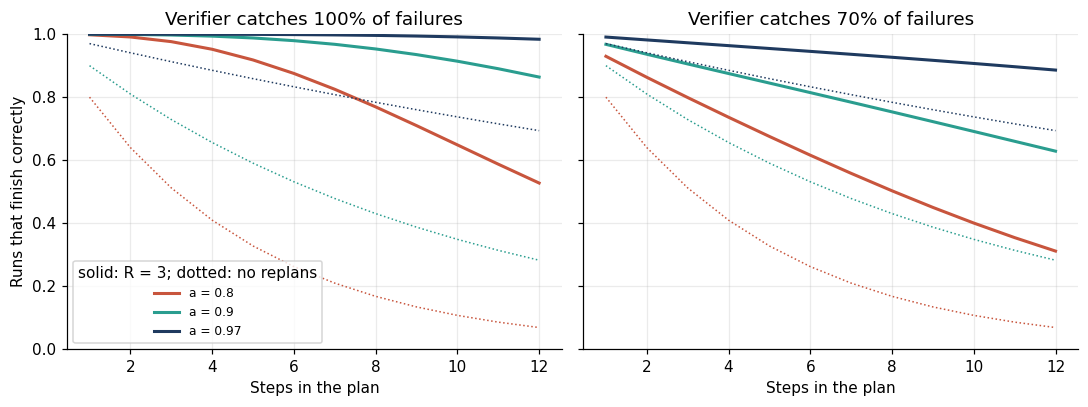

In [3]:
ks = np.arange(1, 13)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, s_ in zip(axes, (1.0, 0.7)):
    for a_, col in zip((0.8, 0.9, 0.97), (WARM, ACCENT, INK)):
        ax.plot(ks, [a_ ** k for k in ks], color=col, ls=":", lw=1)
        ax.plot(ks, [chain(k, a_, s_, 0.05, 3)["correct"] for k in ks], color=col, lw=2, label=f"a = {a_}")
    ax.set(title=f"Verifier catches {s_:.0%} of failures", xlabel="Steps in the plan", ylim=(0, 1))
axes[0].set_ylabel("Runs that finish correctly")
axes[0].legend(title="solid: R = 3; dotted: no replans", fontsize=8)
save(fig, "reliability_vs_steps.png")
R_["correct_k6"] = {f"a={a_},s={s_}": chain(6, a_, s_, 0.05, 3)["correct"] for a_ in (0.8, 0.9, 0.97) for s_ in (1.0, 0.7)}
print({key: round(v, 3) for key, v in R_["correct_k6"].items()})

With a perfect verifier, three replans lift a six-step task at $a = 0.9$ from 53% to 98%. With a
verifier that catches 70% of failures, the same task reaches 81%, and most of the gap is silent
failures. **The verifier, not the planner, sets the ceiling.**

## 3. How far can a "done" be trusted?

The user only ever sees "completed" or "failed", so the question that matters is: of the runs Pilot
reports as complete, what share are wrong? Each step that passes verification was a false pass with
probability

$$q = \frac{(1-a)(1-s)}{a(1-e) + (1-a)(1-s)},$$

so a completed $k$-step run is wrong with probability about $1 - (1-q)^k \approx kq$. The replan cap does
not appear: replans decide how many runs reach the end, not how trustworthy a finished run is.

q = 0.0172; approximate wrong share of completions 1-(1-q)^k = 0.0991
R =  0: silent 0.0430 of all runs; 0.0991 of reported completions
R =  3: silent 0.0933 of all runs; 0.0946 of reported completions
R = 10: silent 0.0944 of all runs; 0.0944 of reported completions
wrong share of completions when a = s: {0.9: np.float64(0.0643), 0.95: np.float64(0.0157), 0.96: np.float64(0.0099), 0.97: np.float64(0.0056)}


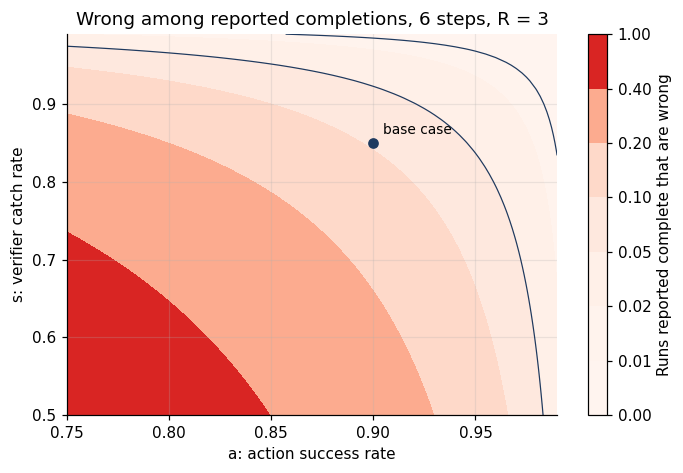

In [4]:
def wrong_share(r):
    """Share of runs reported complete that are actually wrong."""
    return r["silent"] / (r["correct"] + r["silent"])


A = np.linspace(0.75, 0.99, 49)
S = np.linspace(0.50, 0.99, 50)
Z = np.array([[wrong_share(chain(6, a_, s_, 0.05, 3)) for a_ in A] for s_ in S])
fig, ax = plt.subplots(figsize=(6.4, 4.4))
cs = ax.contourf(A, S, Z, levels=[0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.40, 1.0], cmap="Reds")
ax.contour(A, S, Z, levels=[0.01, 0.05], colors=INK, linewidths=0.8)
ax.scatter([base["a"]], [base["s"]], color=INK, zorder=3)
ax.annotate("base case", (base["a"], base["s"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
fig.colorbar(cs, label="Runs reported complete that are wrong")
ax.set(xlabel="a: action success rate", ylabel="s: verifier catch rate", title="Wrong among reported completions, 6 steps, R = 3")
save(fig, "silent_failure_map.png")
a_, s_, e_, k_ = base["a"], base["s"], base["e"], base["k"]
q = (1 - a_) * (1 - s_) / (a_ * (1 - e_) + (1 - a_) * (1 - s_))
R_["false_pass_share_of_passes_q"], R_["wrong_share_approx"] = q, 1 - (1 - q) ** k_
by_R = {R: chain(6, 0.9, 0.85, 0.05, R) for R in (0, 3, 10)}
R_["silent_vs_cap"] = {R: {"silent_share_of_all_runs": r["silent"], "wrong_share_of_completions": wrong_share(r)} for R, r in by_R.items()}
print(f"q = {q:.4f}; approximate wrong share of completions 1-(1-q)^k = {1 - (1 - q) ** k_:.4f}")
for R, r in by_R.items():
    print(f"R = {R:2d}: silent {r['silent']:.4f} of all runs; {wrong_share(r):.4f} of reported completions")
R_["wrong_share_a_eq_s"] = {x: wrong_share(chain(6, x, x, 0.05, 3)) for x in (0.90, 0.95, 0.96, 0.97)}
print("wrong share of completions when a = s:", {x: round(v, 4) for x, v in R_["wrong_share_a_eq_s"].items()})

Raising the cap from 0 to 3 doubles silent failures as a share of *all* runs (4.3% to 9.3%), which looks
alarming until the mechanism is clear: replans rescue runs that would have stopped, and some of those had
already passed a failed step. As a share of *reported completions*, the wrong rate sits near one in ten
(9.9% with no replans, 9.5% with three, 9.4% with ten), close to the approximation's 9.9%. Retries make
Pilot finish more often; they do not make a finish more trustworthy.

The contours run diagonally: a weaker verifier needs a much better actor to keep wrong completions under
5%, and under 1% needs both at about 0.96 or better (0.99% there; 6.4% at 0.90). Spending engineering
effort on more retries is the wrong lever for trust; making the verifier stricter is the right one.

## 4. The 1.5 second wait and the "loading means success" rule

The verifier prompt says: *"If the page is loading or transitioning, set success=true with lower
confidence."* Combined with a fixed 1.5 s wait, any page still settling when the screenshot is taken is
passed, whatever actually happened. If the settle time $T$ is log-normal with median $m$ (an assumption;
real pages vary), the chance the screenshot catches an unsettled page is $u = P(T > 1.5)$, and the
verifier's effective catch rate falls to $s(1-u)$.

The alternative compared here: treat "loading" as **pending**, wait another 1.5 s and look again, up to
three more times. That costs one verifier call per extra look.

m = 0.5 s: unsettled at 1.5 s 5.8%; silent 0.122 now vs 0.093 with pending; +0.39 verifier calls per run
m = 1.0 s: unsettled at 1.5 s 28.1%; silent 0.223 now vs 0.096 with pending; +2.13 verifier calls per run
m = 2.0 s: unsettled at 1.5 s 65.9%; silent 0.366 now vs 0.122 with pending; +6.38 verifier calls per run


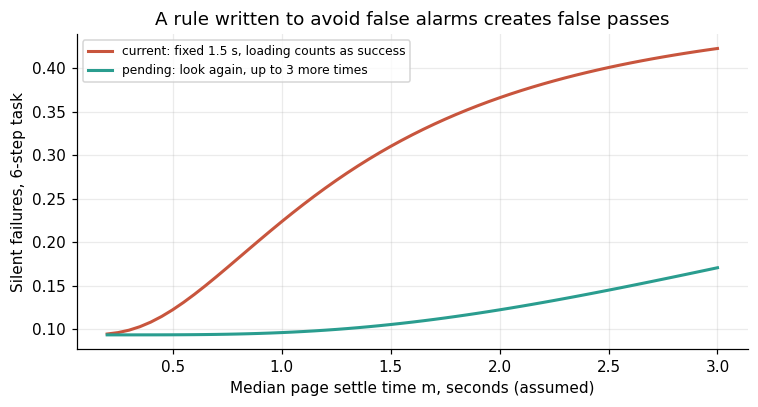

In [5]:
SIGMA = 0.7  # assumed spread of log settle time


def unsettled(m, t):
    return float(stats.lognorm.sf(t, SIGMA, scale=m))


ms = np.linspace(0.2, 3.0, 57)
cur, pend, extra = [], [], []
for m in ms:
    u1 = unsettled(m, WAIT)
    u4 = unsettled(m, 4 * WAIT)
    cur.append(chain(6, 0.9, 0.85 * (1 - u1), 0.05 * (1 - u1), 3)["silent"])
    pend.append(chain(6, 0.9, 0.85 * (1 - u4), 0.05 * (1 - u4), 3)["silent"])
    extra.append(6 * sum(unsettled(m, j * WAIT) for j in (1, 2, 3)))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(ms, cur, color=WARM, lw=2, label="current: fixed 1.5 s, loading counts as success")
ax.plot(ms, pend, color=ACCENT, lw=2, label="pending: look again, up to 3 more times")
ax.set(xlabel="Median page settle time m, seconds (assumed)", ylabel="Silent failures, 6-step task",
       title="A rule written to avoid false alarms creates false passes")
ax.legend(fontsize=8)
save(fig, "settle_time.png")
for m in (0.5, 1.0, 2.0):
    i = int(np.argmin(abs(ms - m)))
    R_[f"settle_m{m}"] = {"unsettled_at_1.5s": unsettled(m, WAIT), "silent_current": cur[i], "silent_pending": pend[i],
                          "extra_verifier_calls_per_run": extra[i]}
    print(f"m = {m} s: unsettled at 1.5 s {unsettled(m, WAIT):.1%}; silent {cur[i]:.3f} now vs {pend[i]:.3f} with pending; "
          f"+{extra[i]:.2f} verifier calls per run")

On a fast page (median settle 0.5 s) the rule fires on about 6% of screenshots and adds about three
points of silent failures (12.2% against 9.3%). At a median of 1 s, 28% of screenshots catch the page
mid-load and silent failures reach 22%; the pending design brings them back to 10% for about two extra
verifier calls per run. On a slow page (median 2 s, plausible for heavy CRM single-page apps), two
screenshots in three are mid-load and silent failures pass one run in three; pending holds them at 12%,
at about six extra calls. The current rule trades a cheap, visible problem (a false alarm and a replan)
for an expensive, invisible one.

## 5. What the replan cap buys

Before the fix, a step that can never succeed (a permissions wall, a button that does not exist) replanned
forever: five model calls per round, with no exit except the user pressing stop. The cap bounds the worst
case at $2 + 3(k + R) + 2R$ calls.

{
"0": {
"correct": 0.3907,
"silent": 0.043,
"stopped": 0.5664,
"calls": 15.0702
},
"1": {
"correct": 0.7133,
"silent": 0.0761,
"stopped": 0.2107,
"calls": 21.0641
},
"2": {
"correct": 0.8517,
"silent": 0.0895,
"stopped": 0.0588,
"calls": 22.8429
},
"3": {
"correct": 0.8933,
"silent": 0.0933,
"stopped": 0.0134,
"calls": 23.2702
},
"6": {
"correct": 0.9055,
"silent": 0.0944,
"stopped": 0.0001,
"calls": 23.3766
}
}
worst-case calls with R = 3, k = 6: 35


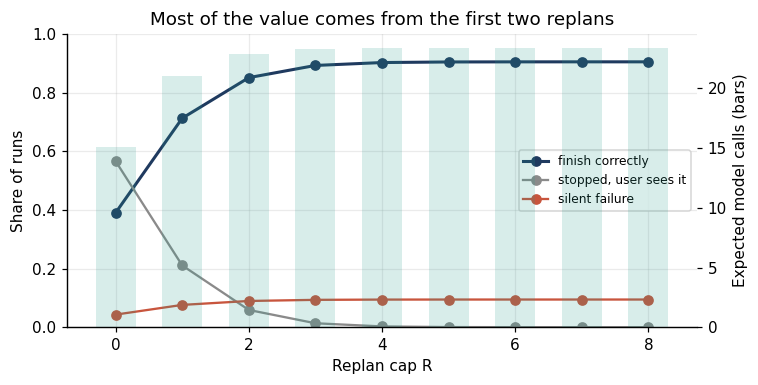

In [6]:
Rs = np.arange(0, 9)
rows = [chain(6, 0.9, 0.85, 0.05, int(R)) for R in Rs]
fig, ax1 = plt.subplots(figsize=(7, 3.6))
ax1.plot(Rs, [r["correct"] for r in rows], color=INK, marker="o", lw=2, label="finish correctly")
ax1.plot(Rs, [r["stopped"] for r in rows], color=GREY, marker="o", lw=1.5, label="stopped, user sees it")
ax1.plot(Rs, [r["silent"] for r in rows], color=WARM, marker="o", lw=1.5, label="silent failure")
ax1.set(xlabel="Replan cap R", ylabel="Share of runs", ylim=(0, 1), title="Most of the value comes from the first two replans")
ax2 = ax1.twinx()
ax2.bar(Rs, [r["calls"] for r in rows], color=ACCENT, alpha=0.18, width=0.6)
ax2.set_ylabel("Expected model calls (bars)")
ax2.grid(False)
ax1.legend(fontsize=8, loc="center right")
save(fig, "replan_cap.png")
R_["by_cap"] = {int(R): {key: round(float(v), 4) for key, v in r.items()} for R, r in zip(Rs, rows)}
R_["worst_case_calls_R3_k6"] = CALLS_START + CALLS_ATTEMPT * (6 + 3) + CALLS_REPLAN * 3
print(json.dumps({R: R_["by_cap"][R] for R in (0, 1, 2, 3, 6)}, indent=0))
print("worst-case calls with R = 3, k = 6:", R_["worst_case_calls_R3_k6"])

Going from no replans to one lifts correct runs from 39% to 71%; three reaches 89% and six only 91%, while
expected calls rise from 15 to 23. Three is a defensible cap: it recovers almost all of what replanning
can recover and bounds a hopeless run at 35 calls instead of infinity.

## 6. Which assumption matters most?

Each rate is swung across a plausible range while the others stay at the base case, and judged two ways:
how often a run finishes correctly, and how far a reported completion can be trusted.

Runs that finish correctly {'e (false alarm)': (np.float64(0.856), np.float64(0.9)), 'k (steps)': (np.float64(0.95), np.float64(0.796)), 's (verifier catch)': (np.float64(0.766), np.float64(0.962)), 'a (action success)': (np.float64(0.736), np.float64(0.972)), 'R (replan cap)': (np.float64(0.391), np.float64(0.906))}
Wrong among reported completions {'e (false alarm)': (np.float64(0.096), np.float64(0.094)), 'R (replan cap)': (np.float64(0.099), np.float64(0.094)), 'k (steps)': (np.float64(0.048), np.float64(0.153)), 'a (action success)': (np.float64(0.199), np.float64(0.027)), 's (verifier catch)': (np.float64(0.23), np.float64(0.02))}


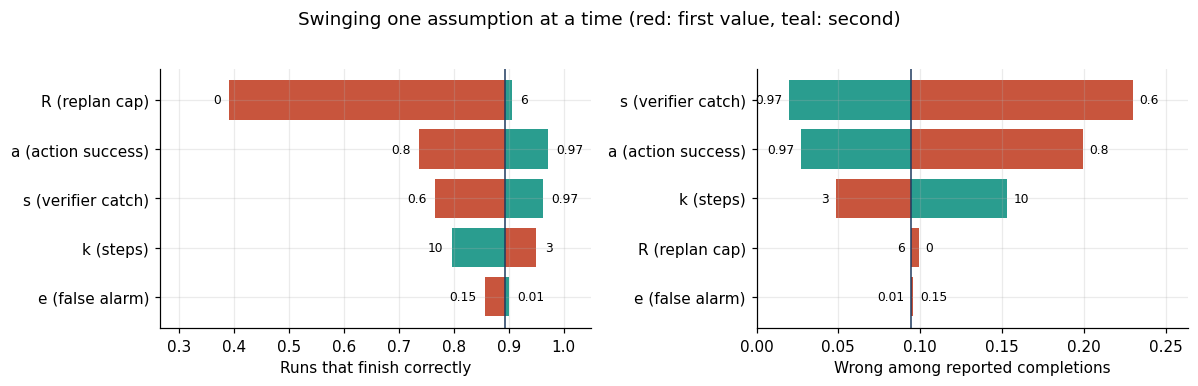

In [7]:
ranges = {"k (steps)": ("k", 3, 10), "a (action success)": ("a", 0.80, 0.97), "s (verifier catch)": ("s", 0.60, 0.97),
          "e (false alarm)": ("e", 0.15, 0.01), "R (replan cap)": ("R", 0, 6)}
metrics = {"Runs that finish correctly": lambda r: r["correct"], "Wrong among reported completions": wrong_share}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
R_["tornado"] = {}
for ax, (mname, f) in zip(axes, metrics.items()):
    centre = f(exact)
    tor = []
    for label, (key, lo, hi) in ranges.items():
        tor.append((label, lo, hi, f(chain(**{**base, key: lo})), f(chain(**{**base, key: hi}))))
    tor.sort(key=lambda t: abs(t[4] - t[3]))
    span = max(max(abs(t[3] - centre), abs(t[4] - centre)) for t in tor)
    for j, (label, lo, hi, vlo, vhi) in enumerate(tor):
        for val, end, col in ((vlo, lo, WARM), (vhi, hi, ACCENT)):
            ax.barh(j, val - centre, left=centre, color=col)
            ax.text(val + (0.03 if val >= centre else -0.03) * span, j, f"{end}", va="center",
                    ha="left" if val >= centre else "right", fontsize=8)
    ax.axvline(centre, color=INK, lw=1)
    ax.set_yticks(range(len(tor)), [t[0] for t in tor])
    ax.set(xlabel=mname, xlim=(max(0, centre - 1.25 * span), min(1.05, centre + 1.25 * span)))
    R_["tornado"][mname] = {t[0]: {"at_low_end": t[3], "at_high_end": t[4]} for t in tor}
    print(mname, {t[0]: (round(t[3], 3), round(t[4], 3)) for t in tor})
fig.suptitle("Swinging one assumption at a time (red: first value, teal: second)", y=1.02)
save(fig, "tornado.png")

For finishing, having replans at all is the biggest lever (39% correct with none, 91% with six), because
without them every caught failure ends the run; action accuracy is next, then the verifier's catch rate,
then plan length. For trust the ranking changes: the replan cap and false alarms barely move the share of
wrong completions (9.4% to 9.9%), while the verifier's catch rate moves it most (23% at 0.60, 2% at 0.97),
followed by action accuracy and plan length. A false alarm costs a replan; a missed failure costs the
user's trust.

## 7. What an evaluation would need to measure

The model says the two rates to pin down are $a$ and $s$. Measuring $s$ needs failed steps, and failures
are rare by design, so waiting for natural failures is slow: at $a = 0.9$ and six steps per task,
collecting enough failures to estimate $s$ within ±0.10 takes about 80 tasks.

In [8]:
def failures_needed(p, half_width):
    z = stats.norm.ppf(0.975)
    return int(np.ceil(z ** 2 * p * (1 - p) / half_width ** 2))


n_fail = failures_needed(0.85, 0.10)
R_["failed_steps_needed_for_s"] = n_fail
R_["tasks_needed_natural"] = int(np.ceil(n_fail / (6 * (1 - 0.9))))
print(f"failed steps needed to estimate s = 0.85 within ±0.10: {n_fail}; "
      f"tasks needed if failures occur naturally (a = 0.9, 6 steps): {R_['tasks_needed_natural']}")

failed steps needed to estimate s = 0.85 within ±0.10: 49; tasks needed if failures occur naturally (a = 0.9, 6 steps): 82


A sharper design is **fault injection**: run scripted tasks on a demo app with a ground-truth check (the
DOM state after each step), and deliberately break some steps (disable the target button, delay the page
by 3 seconds, move an element). Each injected fault is a labelled failure, so about 50 of them estimate
$s$ to ±0.10, and the delayed-page faults test the settle-time problem from section 4 directly.

## 8. Code review findings

| # | Finding | Severity | Status |
|---|---|---|---|
| 1 | A step that keeps failing replans forever (no counter in the session) | High | **Fixed**: `MAX_REPLANS = 3`, reset per goal; 5 tests |
| 2 | Screenshots are in device pixels but CDP clicks take CSS pixels, so on a Retina Mac every click lands at twice the intended coordinates | High | **Fixed** in `extension/src/background.js` (divide by `devicePixelRatio`); needs a manual check in Chrome |
| 3 | The action prompt never states the screenshot size, and out-of-bounds coordinates were clicked anyway | Medium | **Fixed**: size read from the PNG header into the prompt; out-of-bounds clicks fail the step; 6 tests |
| 4 | Verifier prompt passes any page that is still loading | High | Recommended: a `pending` verdict and another look (section 4); not changed, because a prompt change cannot be tested without a key |
| 5 | The verifier's confidence is returned and never used | Medium | Recommended: a low-confidence pass triggers a second screenshot |
| 6 | The expected outcome is generic ("The UI should reflect the completion of: {step}") | Medium | Recommended: the planner emits a concrete expected outcome per step for the verifier to check |
| 7 | An unparseable plan becomes a single step, "Attempt to: {goal}" | Medium | Recommended: retry the parse or fail visibly; a vague step is the hardest kind to verify |
| 8 | Fixed 1.5 s wait before verifying | Medium | Recommended: wait until two consecutive screenshots match, with a timeout |
| 9 | `list[str] \| None` annotations fail on Python 3.9 | Low | **Fixed**: `from __future__ import annotations` |
| 10 | Docstrings say "Gemini 3.1 Pro"; the code pins `gemini-2.5-pro` | Low | **Fixed** |
| 11 | The WebSocket does not check the `Origin` header, and browsers do not apply CORS to WebSockets | Low | Recommended: accept only the extension's origin |

**The pattern behind 4 to 8:** the agent's safety rests on the verifier, and the verifier is given a vague
question, a page that may still be loading, and an instruction to say yes when unsure. The cheapest
reliability gains are there, not in the planner or the replan logic.

In [9]:
(ROOT / "results").mkdir(exist_ok=True)
(ROOT / "results" / "reliability_model.json").write_text(json.dumps(R_, indent=1, default=float))
print("saved results/reliability_model.json; every rate in it is an assumption, not a measurement")

saved results/reliability_model.json; every rate in it is an assumption, not a measurement
